In [19]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver

In [20]:
load_dotenv()
llm = ChatGroq(model="moonshotai/kimi-k2-instruct-0905")


In [21]:
class JokeState(TypedDict):
    topic: str
    joke: str
    explanation : str

In [22]:
def generate_joke(state: JokeState) -> JokeState:
    
    prompt = f"""
    You are a joke generator. 
    Generate a joke about {state['topic']}.
    """
    response = llm.invoke(prompt)
    return {"joke": response.content}

In [23]:
def explain_joke(state: JokeState) -> JokeState:
    prompt = f"""
    You are an explainer. 
    Explain the joke {state['joke']} in a funny way.
    """
    response = llm.invoke(prompt)
    return {"explanation": response.content}

In [24]:
graph = StateGraph(JokeState)

graph.add_node("generate_joke", generate_joke)
graph.add_node("explain_joke", explain_joke)

graph.add_edge(START, "generate_joke")
graph.add_edge("generate_joke", "explain_joke")
graph.add_edge("explain_joke", END)

checkpointer = InMemorySaver()
workflow = graph.compile(checkpointer=checkpointer)

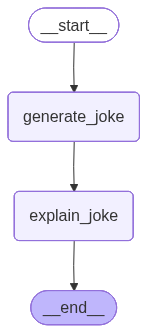

In [26]:
workflow

In [ ]:
config1 = {"configurable": {"thread_id": "1"}}
workflow.invoke({"topic": "cats"}, config=config1)
len(list(workflow.get_state_history(config1))) # no. of checkpoints


4